#Reinforcement Learning project: The Blackjack dream.



In [ ]:
import random
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

##Basic strategy evaluation.

Let's first create our Blackjack class. We will use it to simulate a blackjack round/game with a dealer and a single player that follows the BASIC STRATEGY (obtained from https://www.techopedia.com/gambling-guides/blackjack-strategy). The idea is to simulate many rounds to analyze the player's chances.

In [ ]:
class BlackjackBS():
  def __init__(self, bjRatio=(3/2), playersMoney=100, minBet=10, nDecks=6, hitsSoft17=True, doubleAfterSplit=True):
    '''
    bjRatio: the ratio that the house pays when the player gets a blackjack AND the dealer doesn't. If 3 to 2, then the house pays 1.5 the bet.
    playersMoney: the total money on the player's wallet.
    minBet: the minimum bet requiered to enter the table, we asume that the player will always bet this amount.
    nDecks: number of decks to be used.
    hitsSoft17: True or False depending whether the dealer hits on Ace and 6 or doesn't.
    doubleAfterSplit: indicates whether the player can double down after splitting.
      Observations:
    We won't allow the player to surrender since most casinos don't have this variant.
    We won't consider insurance (according to the basic strategy the player most never buy it anyways).
    For the coding we won't consider the card suits since they don't matter in this game.
    The player will only get one more card if he doubles down.
    We asume that the player will always have money for splitting or doubling down (meaning he can have negative earnings).
    '''
    self.bjRatio = bjRatio
    self.playersMoney = playersMoney
    self.minBet = minBet
    self.nDecks = nDecks
    self.hitsSoft17 = hitsSoft17
    self.doubleAfterSplit = doubleAfterSplit
    self.values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] #11 will be treated as an ace
    self.whichDeck = 'original' #'original' indicates the original deck, 'remainder' for when the shuffled remainder of the deck is being used
    #to continue the hand in case the original deck is empty in the middle of a round.
    self.wins = defaultdict(int) #dictonary containing the count for wins for 'player' and 'dealer' and the amount of 'pushes'
    self.shuffle()
    self.remainder = [] #contains the cards played after each round.
    self.dealer = [] #dealer's hand
    self.player = [[]] #player's hand, a list of lists (since he can have multiple hands after splitting)
    self.doubledDown = [False] #boolean values indicating whether a hand has been doubled down
    self.numSplits = 0 #to later obtain the total number of hands played

  def shuffle(self):
    if self.whichDeck=='original':
      self.deck = [value for value in self.values for i in range(4)] * self.nDecks
      random.shuffle(self.deck)
      self.remainder = []
    elif self.whichDeck=='remainder':
      random.shuffle(self.remainder)
      self.deck = self.remainder.copy()
      self.remainder = []

  def checkCardsLeft(self):
    '''
    In case there are no more cards left in the deck, it shuffles and uses the remaining cards to finish the hand.
    It is called when someone wishes to hit.
    '''
    if len(self.deck) == 0: #no more cards left
      self.whichDeck = 'remainder'
      self.shuffle()
    else:
      return

  def hit(self, who, index=0):
    '''
    who: 'dealer' or 'player'.
    index: the index of the hand that the player wants to hit (in case he splitted).
    '''
    self.checkCardsLeft()
    if who=='dealer':
      self.dealer.append(self.deck.pop())
    elif who=='player':
      self.player[index].append(self.deck.pop())

  def dealersTurn(self):
    '''
    Hits until the sum is more or equal to 17. Handles special case of soft 17 and of aces valued as 11 needing to change to 1.
    '''
    while sum(self.dealer) < 17:
      self.hit('dealer')
      if sum(self.dealer) > 21 and 11 in self.dealer:
        ind = self.dealer.index(11)
        self.dealer[ind] = 1
      if sum(self.dealer) == 17 and 11 in self.dealer and self.hitsSoft17: #soft 17
        self.hit('dealer')
        if sum(self.dealer) > 21:
          ind = self.dealer.index(11)
          self.dealer[ind] = 1

  def win(self, blackjack=False, doubledDown=False):
    self.wins['player'] += 1
    if blackjack:
      self.playersMoney += self.minBet + self.bjRatio*self.minBet
    else:
      if not doubledDown:
        self.playersMoney += 2*self.minBet
      else:
        self.playersMoney += 4*self.minBet

  def loss(self):
    self.wins['dealer'] += 1

  def push(self):
    self.wins['pushes'] += 1
    self.playersMoney += self.minBet

  def split(self, index):
    '''
    Obtains the index of the hand the player wishes to split (in case he already has more than one hand).
    Returns the splited hand, for example [[4, 5], [2, 2]] returns [[4, 5], [2], [2]] for index=1
    '''
    self.playersMoney -= self.minBet
    splitted = []
    for i, hand in enumerate(self.player):
      if i == index:
        splitted.extend([[item] for item in hand])
      else:
        splitted.append(hand)
    self.player = splitted
    self.doubledDown[index:index+1] = [False, False]

  def simulation(self, n):
    '''
    n: number of rounds to simulate.
    We created this function since we can't include a for loop in round() because we call it recursively in
    case of a split.
    '''
    for _ in range(n):
      self.round()

  def round(self):
    '''
    Conducts a single round of blackjack, from when the player places his bet to when the round finishes and
    the player is handed money or not.
    '''
    #dealer hands cards:
    if self.player==[[]]: #this means the function hasn't been called recursively after a split
      self.playersMoney -= self.minBet
      self.hit('player', 0)
      self.hit('dealer')
      self.hit('player', 0)
      self.hit('dealer')
    else: #the dealer gives a card to each hand after a split
      for index, hand in enumerate(self.player):
        if len(hand) == 1:
          self.hit('player', index)

    #player's decisions:
    for index, hand in enumerate(self.player):
      #win or loose will be determined after the for loop

      #player gets a hand where he must split
      if hand[0] == hand[1] and len(hand)==2: #pair
        def func(p, a, b):
          return hand[0]==p and self.dealer[-1] in range(a, b+1)
        if self.doubleAfterSplit:
          if hand[0]==11 or hand[0]==8 or func(2,2,7) or func(3,2,7) or func(4,5,6) or func(6,2,6) or func(7,2,7) or func(9,2,6) or func(9,8,9):
            #split:
            self.split(index)
            self.round()
            return
        else:
          if hand[0]==11 or hand[0]==8 or func(2,4,7) or func(3,4,7) or func(6,3,6) or func(7,2,7) or func(9,2,6) or func(9,8,9):
            #split:
            self.split(index)
            self.round()
            return

      #player gets a blackjack or a hand where he must stand
      #blackjack = hand[0]+hand[1]==21
      twentyOne = sum(hand)==21
      cond1 = hand[0]==hand[1]==10
      cond2 = hand[0]==hand[1]==9 and self.dealer[-1] in (7,10,11) and len(hand)==2
      if 11 in hand:
        indx11 = hand.index(11)
        cond3 = sum(hand[:indx11] + hand[indx11+1:])==8
        cond4 = sum(hand[:indx11] + hand[indx11+1:])==7 and self.dealer[-1] in (2,7,8)
        cond8 = sum(hand[:indx11] + hand[indx11+1:])==7 and self.dealer[-1] in range(3, 7) and len(hand)>2
      else:
        cond3 = False
        cond4 = False
        cond8 = False
      cond5 = sum(hand)==17 and 11 not in hand
      cond6 = sum(hand)==12 and 11 not in hand and self.dealer[-1] in (4,5,6)
      cond7 = sum(hand) in range(13, 17) and 11 not in hand and self.dealer[-1] in range(2, 7)
      if twentyOne or cond1 or cond2 or cond3 or cond4 or cond5 or cond6 or cond7 or cond8:
        #stand:
        continue

      #Se usan en los ifs de abajo:
      def func1(s, a, b):
        return sum(hand)==s and self.dealer[-1] in range(a, b+1) and 11 not in hand
      def func2(p, a, b):
        if 11 in hand:
          indx11 = hand.index(11)
          return sum(hand[:indx11] + hand[indx11+1:])==p and self.dealer[-1] in range(a, b+1)
        else:
          return False
      def func3(p, a, b):
        return len(hand)==2 and hand[0]==hand[1]==p and self.dealer[-1] in range(a, b+1)

      #player gets a sum straight away (without hitting) where he must double down
      if len(hand)==2:
        if func1(9,3,6) or func1(10,2,9) or sum(hand)==11 or func2(2,5,6) or func2(3,5,6) or func2(4,4,6) or func2(5,4,6) or func2(6,3,6) or func2(7,3,6) or func3(5,2,9):
          if self.doubleAfterSplit or (not self.doubleAfterSplit and len(self.player)==1):               ###!! added
            #double down:
            self.playersMoney -= self.minBet               ###!! must be paid 4 times initial bet then
            self.hit('player', index)
            self.doubledDown[index] = True
            continue
          elif not self.doubleAfterSplit and len(self.player)>1:
            #hit
            self.hit('player', index)
            self.round()
            return

      elif len(hand)>2: #after hitting
        if func1(9,3,6) or func1(10,2,9) or sum(hand)==11 or func2(2,5,6) or func2(3,5,6) or func2(4,4,6) or func2(5,4,6) or func2(6,3,6):
          if not self.doubledDown[index]:
            #hit:
            self.hit('player', index)
            self.round()
            return
          else:
            continue

      #player has a hand where he must hit
      cond1 = sum(hand)<=8 or func1(9,2,2) or func1(9,7,11) or func1(10,10,11) or func1(12,2,3)
      cond2 = any([func1(i,7,11) for i in range(12, 17)])
      cond3 = func2(2,2,4) or func2(3,2,4) or func2(4,2,3) or func2(5,2,3) or func2(6,2,2) or func2(7,9,11)
      cond4 = any([func2(i,7,11) for i in range(2, 7)])
      if self.doubleAfterSplit:
        cond5 = func3(2,8,11) or func3(3,8,11) or func3(4,2,4) or func3(4,7,11) or func3(5,10,11) or func3(6,7,11) or func3(7,8,11)       #
      else:
         cond5 = func3(2,2,3) or func3(2,8,11) or func3(3,2,3) or func3(3,8,11) or func3(4,2,11) or func3(5,10,11) or func3(6,2,2) or func3(6,7,11) or func3(7,8,11)
      if cond1 or cond2 or cond3 or cond4 or cond5:
        if not self.doubledDown[index]:
          #hit:
          self.hit('player', index)
          self.round()
          return
        else:
          continue

        ind = self.dealer.index(11)
        self.dealer[ind] = 1

      #player has more than 21
      if sum(hand)>21:
        if 11 in hand:
          #we replace the first 11 with a 1
          ind = hand.index(11)
          hand[ind] = 1
          self.player[index] = hand
          self.round()
          return
      else:
        continue

    #End of round, now comes the dealer's turn and discover who won
    self.dealersTurn()

    for index, hand in enumerate(self.player):
      if hand[0]+hand[1]==21 and self.dealer[0]+self.dealer[1]!=21:
        self.win(blackjack=True) #blackjack
      elif hand[0]+hand[1]==21 and self.dealer[0]+self.dealer[1]==21:
        self.push()
      elif self.dealer[0]+self.dealer[1]==21:
        self.loss()
      elif sum(hand)>21:
        self.loss()
      elif sum(hand)==21:
        if sum(self.dealer)==21:
          self.push()
        else:
          if self.doubledDown[index]:
            self.win(blackjack=False, doubledDown=True)
          else:
            self.win(blackjack=False, doubledDown=False)
      elif sum(self.dealer)==sum(hand):
        self.push()
      elif sum(hand)>sum(self.dealer):
        if self.doubledDown[index]:
          self.win(blackjack=False, doubledDown=True)
        else:
          self.win(blackjack=False, doubledDown=False)
      elif sum(hand)<sum(self.dealer):
        if sum(self.dealer)>21:
          if self.doubledDown[index]:
            self.win(blackjack=False, doubledDown=True)
          else:
            self.win(blackjack=False, doubledDown=False)
        else:
          self.loss()

    #Finally we check if we used the original or remainder deck in this round:
    if self.whichDeck=='remainder':
      #we shuffle all the cards and set the remainder deck to an empty list
      self.whichDeck = 'original'
      self.shuffle()
    elif self.whichDeck=='original':
      #we add the played cards to the remainder deck
      self.remainder.extend(self.dealer)
      self.remainder.extend(item for sublist in self.player for item in sublist)

    self.numSplits += len(self.player)-1
    #we empty the hands
    self.dealer = []
    self.player = [[]]
    self.doubledDown = [False]

Let's now simulate a million rounds to see the overall number of wins, losses, and pushes/ties.

In [ ]:
n = 1000000
bj = BlackjackBS()
bj.simulation(n)

handsPlayed = n + bj.numSplits

print('\t1,000,000 blackjack hands simulation playing a perfect basic strategy\n')
print(f'Player\'s money: {bj.playersMoney}')
print(f'Results dictionary: {bj.wins}')
print('\n')
print(f'Win percentage: {(bj.wins["player"]/handsPlayed)*100:.2f}%')
print(f'Loss percentage: {(bj.wins["dealer"]/handsPlayed)*100:.2f}%')
print(f'Push percentage: {(bj.wins["pushes"]/handsPlayed)*100:.2f}%')

	1,000,000 blackjack hands simulation playing a perfect basic strategy

Player's money: -348990.0
Results dictionary: defaultdict(<class 'int'>, {'player': 443716, 'dealer': 498673, 'pushes': 87020})


Win percentage: 43.10%
Loss percentage: 48.44%
Push percentage: 8.45%


Now let's simulate for several number of rounds to look at the distribution of the player's earnings.

In [ ]:
def montecarlo(rounds=[30], n=10000):
  '''
  Obtains several graphs for the distribution of the earnings for different number of rounds.
  '''
  plt.figure(figsize=(10, 7))
  plt.title('Earnings after different number of rounds')
  plt.xlabel('$')
  for i in rounds:
    arr = []
    for _ in range(n):
      bj = BlackjackBS()
      bj.simulation(i)
      arr.append(bj.playersMoney)
    sns.kdeplot(arr, label=f'{i} rounds, mean: {np.mean(arr):.2f}, std: {np.std(arr):.2f}');
  plt.axvline(100, color='black', linestyle='--', label='$100 (initial money)')
  plt.legend()

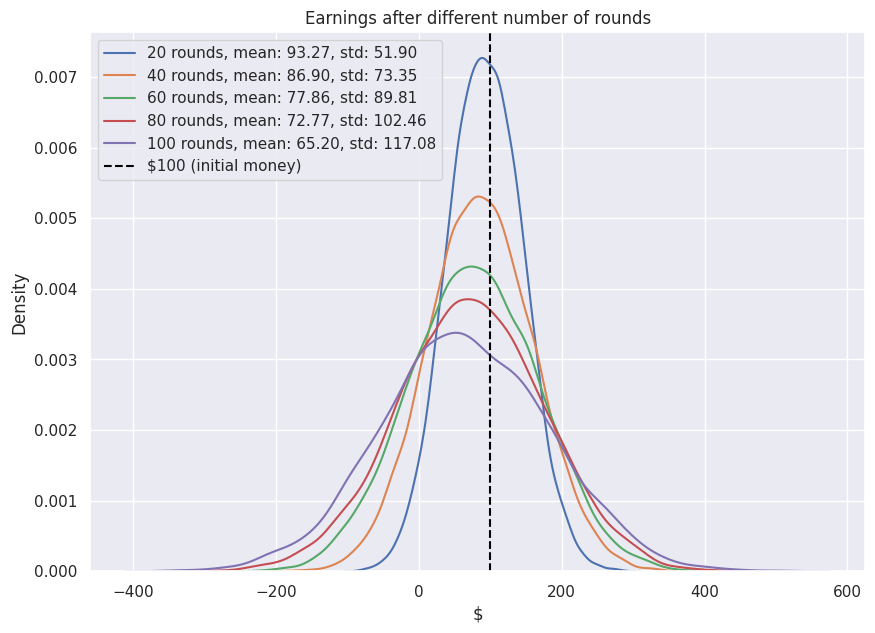

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
montecarlo([20, 40, 60, 80, 100], 10000)

We see that our expected earning decrease and the variance increases the more rounds we play.

##Creating our agent.

In [10]:
# -----------------------------
# Helpers: hand values
# -----------------------------
def hand_value(cards: List[int]) -> Tuple[int, bool]:
    """
    Returns (best_total, usable_ace_as_11).
    Cards use: 2-10 as pip, 10 repeated for face cards, Ace as 11 initially.
    """
    total = sum(cards)
    aces = cards.count(11)
    # Convert Aces 11 -> 1 as needed
    while total > 21 and aces > 0:
        total -= 10
        aces -= 1
    usable_ace = (11 in cards) and (sum(cards) <= 21) and (total != sum([1 if c == 11 else c for c in cards]))
    # The 'usable_ace' definition above is finicky; better:
    # usable_ace means: there exists an ace counted as 11 in the chosen total.
    # Let's compute it more directly:
    # If there's at least one ace, and total <= 21, and if treating one ace as 11 is possible:
    if 11 in cards:
        # total we computed is with some aces possibly downgraded; to see if any ace is still 11,
        # compare with "all aces as 1" baseline
        baseline = sum([1 if c == 11 else c for c in cards])
        usable_ace = (total == baseline + 10)  # exactly one ace counted as 11 (or more, but in BJ only one matters)
    else:
        usable_ace = False
    return total, usable_ace


# -----------------------------
# Environment
# -----------------------------
@dataclass
class HandStatus:
    cards: List[int]
    stood: bool = False
    doubled: bool = False
    busted: bool = False
    blackjack: bool = False  # natural 21 on first two cards


class BlackjackDream:
    """
    Multi-hand blackjack environment:
    - actions: 0=stand, 1=hit, 2=double, 3=split
    - split allowed only when exactly two cards and same rank/value (we treat values, so 10s are "same").
    - double allowed only when hand has exactly two cards.
    - dealer hits soft 17 configurable.
    - shoe: nDecks decks; if shoe empties mid-round, uses remainder.
    - state vector (28):
        0..11  : normalized counts of 2..A seen so far (13 features)
        13..21 : dealer upcard one-hot for 2..A (10 features)  [we encode 2-11 => indices 13..22?]
        23     : player total / 21
        24     : num cards in current hand / 10  (cap)
        25     : usable ace flag (0/1)
        26     : pair flag (0/1)
        27     : has split flag (0/1) (ever in this round)
    """
    def __init__(self, nDecks=6, hitsSoft17=True, seed: Optional[int]=None):
        self.nDecks = nDecks
        self.hitsSoft17 = hitsSoft17
        self.rng = random.Random(seed)

        # Card values: 2-10, J/Q/K as 10, Ace as 11
        self.values = [2,3,4,5,6,7,8,9,10,10,10,10,11]
        self.actions = {"stand":0, "hit":1, "double":2, "split":3}
        self.n_actions = 4

        # shoe / remainder
        self.whichDeck = "original"
        self.deck = []
        self.remainder = []

        # round state
        self.dealer: List[int] = []
        self.hands: List[HandStatus] = []
        self.active_hand_index: int = 0
        self.has_split_flag: int = 0

        # state vector
        self.state = np.zeros(28, dtype=np.float32)

        self.shuffle()

    def shuffle(self):
        if self.whichDeck == "original":
            self.state[:] = 0.0
            self.deck = [v for v in self.values for _ in range(4)] * self.nDecks
            self.rng.shuffle(self.deck)
            self.remainder = []
        else:  # remainder
            self.rng.shuffle(self.remainder)
            self.deck = self.remainder.copy()
            self.remainder = []

    def _check_cards_left(self):
        if len(self.deck) == 0:
            self.whichDeck = "remainder"
            self.shuffle()

    def _pop_card(self, register_in_state=True) -> int:
        self._check_cards_left()
        c = self.deck.pop()
        self.remainder.append(c)

        if register_in_state:
            # 0..12 = counts of 2..A
            idx = (c - 2) if c != 11 else 12
            self.state[idx] += 1.0 / (4.0 * self.nDecks)

            # running count feature (Hi/Lo) into state[21] scaled/clipped to [-1,1]
            # We'll keep it in state[21] and clip
            if c in [2,3,4,5,6]:
                self.state[21] = min(1.0, self.state[21] + 0.1)
            elif c in [10,11]:
                self.state[21] = max(-1.0, self.state[21] - 0.1)

            # cards seen proportion (state[22]) scaled 0..1 roughly; 10*4*nDecks
            self.state[22] = min(1.0, self.state[22] + 1.0 / (10.0 * 4.0 * self.nDecks))

        return c

    def _dealer_up_onehot(self, upcard: int):
        # one-hot for dealer upcard 2..11 -> 10 slots
        # store in state[13..22] (10 entries)
        self.state[13:23] = 0.0
        slot = (upcard - 2) if upcard != 11 else 9  # 2->0 ... 10->8, A(11)->9
        self.state[13 + slot] = 1.0

    def _update_player_features(self):
        hand = self.hands[self.active_hand_index].cards
        total, usable = hand_value(hand)
        self.state[23] = max(0.0, min(1.0, total / 21.0))
        self.state[24] = min(1.0, len(hand) / 10.0)
        self.state[25] = 1.0 if usable else 0.0
        self.state[26] = 1.0 if (len(hand) == 2 and hand[0] == hand[1]) else 0.0
        self.state[27] = float(self.has_split_flag)

    def reset(self) -> np.ndarray:
        # If we used remainder deck in previous round, return to original shoe for next round
        if self.whichDeck == "remainder":
            self.whichDeck = "original"
            self.shuffle()

        self.dealer = []
        self.hands = [HandStatus(cards=[])]
        self.active_hand_index = 0
        self.has_split_flag = 0

        # initial deal: player, dealer, player, dealer(upcard registered)
        self.hands[0].cards.append(self._pop_card())
        self.dealer.append(self._pop_card())
        self.hands[0].cards.append(self._pop_card())
        up = self._pop_card()
        self.dealer.append(up)
        self._dealer_up_onehot(up)

        # set natural blackjack flags
        pt, _ = hand_value(self.hands[0].cards)
        if pt == 21 and len(self.hands[0].cards) == 2:
            self.hands[0].blackjack = True

        self._update_player_features()
        return self.state.copy()

    def legal_actions(self) -> List[int]:
        h = self.hands[self.active_hand_index]
        if h.stood or h.doubled or h.busted or h.blackjack:
            return [self.actions["stand"]]  # won't be used; episode logic advances hand

        actions = [self.actions["stand"], self.actions["hit"]]
        # double only on exactly 2 cards
        if len(h.cards) == 2:
            actions.append(self.actions["double"])
            # split only on pair on exactly 2 cards
            if h.cards[0] == h.cards[1]:
                actions.append(self.actions["split"])
        return actions

    def _advance_to_next_hand_or_dealer(self) -> bool:
        """
        Returns True if round is over (dealer resolved and reward can be computed).
        """
        # find next hand that can act
        for i in range(self.active_hand_index + 1, len(self.hands)):
            hi = self.hands[i]
            if not (hi.stood or hi.doubled or hi.busted or hi.blackjack):
                self.active_hand_index = i
                self._update_player_features()
                return False

        # none left -> dealer plays if at least one hand not busted (blackjack also counts)
        self._dealers_turn()
        return True

    def _dealers_turn(self):
        while True:
            total, usable = hand_value(self.dealer)
            if total > 21:
                return
            if total < 17:
                self.dealer.append(self._pop_card(register_in_state=True))
                continue
            if total == 17 and usable and self.hitsSoft17:
                self.dealer.append(self._pop_card(register_in_state=True))
                continue
            return

    def _resolve_hand(self, hand: HandStatus) -> int:
        """
        Returns reward for that hand in units:
        win: +1 (or +2 if doubled), loss: -1 (or -2 if doubled), push: 0.
        We'll treat it as a normal win (+1) vs dealer non-bj, push vs dealer bj.
        """
        bet_mult = 2 if hand.doubled else 1

        player_total, _ = hand_value(hand.cards)
        dealer_total, _ = hand_value(self.dealer)

        # bust
        if player_total > 21:
            return -1 * bet_mult

        # dealer bust
        if dealer_total > 21:
            return +1 * bet_mult

        # natural blackjack handling
        if hand.blackjack:
          dealer_bj = (dealer_total == 21 and len(self.dealer) == 2)
          return 0 if dealer_bj else 1.5 # blackjack pays 3:2

        # compare totals
        if player_total > dealer_total:
            return +1 * bet_mult
        elif player_total < dealer_total:
            return -1 * bet_mult
        else:
            return 0

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        """
        One decision step for the currently active hand.
        Returns: next_state, reward, done, info
        Reward is 0 until terminal (end of round), then sum of all hand rewards.
        """
        h = self.hands[self.active_hand_index]
        info = {}

        # If current hand cannot act, advance
        if h.stood or h.doubled or h.busted or h.blackjack:
            done = self._advance_to_next_hand_or_dealer()
            if done:
                R = sum(self._resolve_hand(x) for x in self.hands)
                self.reset()
            self._update_player_features()
            return self.state.copy(), 0.0, False, info

        legal = self.legal_actions()
        if action not in legal:
            # penalize illegal actions mildly and treat as hit (or stand).
            # Here: treat illegal as hit to keep things moving.
            info["illegal_action"] = True
            action = self.actions["hit"]

        if action == self.actions["hit"]:
            h.cards.append(self._pop_card())
            total, _ = hand_value(h.cards)
            if total > 21:
                h.busted = True

        elif action == self.actions["stand"]:
            h.stood = True

        elif action == self.actions["double"]:
            h.doubled = True
            h.cards.append(self._pop_card())
            total, _ = hand_value(h.cards)
            if total > 21:
                h.busted = True
            # after double the player stands automatically
            h.stood = True

        elif action == self.actions["split"]:
            # split into two hands, each gets one of the pair, then each gets one new card
            self.has_split_flag = 1
            c1, c2 = h.cards
            # replace current hand with first card
            h.cards = [c1]
            # create new hand with second card right after current
            new_hand = HandStatus(cards=[c2])
            self.hands.insert(self.active_hand_index + 1, new_hand)

            # deal one card to each split hand
            h.cards.append(self._pop_card())
            new_hand.cards.append(self._pop_card())

            # set blackjack flags (usually split aces rules differ; ignore for now)
            for hh in (h, new_hand):
                pt, _ = hand_value(hh.cards)
                if pt == 21 and len(hh.cards) == 2:
                    hh.blackjack = True

        # after action, advance if hand is finished
        if h.stood or h.busted or h.blackjack:
            done = self._advance_to_next_hand_or_dealer()
            if done:
                reward = float(sum(self._resolve_hand(x) for x in self.hands))
                self._update_player_features()
                return self.state.copy(), reward, True, info

        self._update_player_features()
        return self.state.copy(), 0.0, False, info

We implement SARSA(lambda):

In [11]:

# -----------------------------
# TD(lambda): SARSA(lambda) with linear function approximation
# Q(s,a) = w_a · s
# -----------------------------
class SarsaLambdaLinear:
    def __init__(self, n_features: int, n_actions: int, alpha=0.01, gamma=1.0, lam=0.7, epsilon=0.1, seed=None):
        self.n_features = n_features
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

        # weights per action
        self.W = np.zeros((n_actions, n_features), dtype=np.float32)
        # eligibility traces per action
        self.E = np.zeros_like(self.W)

    def q_values(self, s: np.ndarray) -> np.ndarray:
        return self.W @ s  # (A,F) dot (F,) -> (A,)

    def select_action(self, s: np.ndarray, legal_actions: List[int]) -> int:
        if self.rng.random() < self.epsilon:
            return int(self.rng.choice(legal_actions))
        q = self.q_values(s)
        # mask illegal
        masked = np.full(self.n_actions, -1e9, dtype=np.float32)
        for a in legal_actions:
            masked[a] = q[a]
        return int(np.argmax(masked))

    def start_episode(self):
        self.E[:] = 0.0

    def update(self, s: np.ndarray, a: int, r: float, s2: np.ndarray, a2: Optional[int], terminal: bool):
        """
        SARSA(lambda) backward view with accumulating traces:
          delta = r + gamma*Q(s2,a2) - Q(s,a) (terminal => Q(s2,a2)=0)
          E[a] += s
          W += alpha * delta * E
          E *= gamma*lambda
        """
        q_sa = float(self.W[a] @ s)
        q_next = 0.0 if terminal or a2 is None else float(self.W[a2] @ s2)
        delta = r + self.gamma * q_next - q_sa

        # accumulating trace for chosen action
        self.E[a] += s

        # weight update
        self.W += self.alpha * delta * self.E

        # decay traces
        self.E *= (self.gamma * self.lam)

Now we will train and evaluate our agent. We'll obtains win rates for our agent, a vanilla strategy where the player hits on a sum <=16 and stands on >=17, and the basic strategy:

In [17]:

# -----------------------------
# Training + Evaluation
# -----------------------------
def train(env: BlackjackDream,
          agent: SarsaLambdaLinear,
          episodes: int = 200_000,
          log_every: int = 10_000) -> Dict[str, float]:

    stats = {"episodes": 0, "avg_return": 0.0}
    returns = []

    for ep in range(1, episodes + 1):
        s = env.reset()
        agent.start_episode()

        legal = env.legal_actions()
        a = agent.select_action(s, legal)

        G = 0.0
        done = False

        while not done:
            s2, r, done, info = env.step(a)
            G += r

            if not done:
                legal2 = env.legal_actions()
                a2 = agent.select_action(s2, legal2)
            else:
                a2 = None

            agent.update(s, a, r, s2, a2, terminal=done)

            s, a = s2, (a2 if a2 is not None else 0)

        returns.append(G)

        if ep % log_every == 0:
            avg = float(np.mean(returns[-log_every:]))
            print(f"Episode {ep:,} | avg return last {log_every:,}: {avg:.4f}")

    stats["episodes"] = episodes
    stats["avg_return"] = float(np.mean(returns))
    return stats


def evaluate(env: BlackjackDream,
             agent: SarsaLambdaLinear,
             episodes: int = 50_000,
             epsilon_eval: float = 0.0) -> Dict[str, float]:

    old_eps = agent.epsilon
    agent.epsilon = epsilon_eval

    wins = pushes = losses = 0
    total_return = 0.0

    for _ in range(episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            legal = env.legal_actions()
            a = agent.select_action(s, legal)
            s, r, done, info = env.step(a)
            ep_return += r

        total_return += ep_return
        # For rates: interpret per-round return sign (multi-hand splits can yield -2..+2 etc).
        # We'll classify: >0 win, ==0 push, <0 loss.
        if ep_return > 0:
            wins += 1
        elif ep_return < 0:
            losses += 1
        else:
            pushes += 1

    agent.epsilon = old_eps

    return {
        "episodes": episodes,
        "win_rate": wins / episodes,
        "push_rate": pushes / episodes,
        "loss_rate": losses / episodes,
        "avg_return_per_round": total_return / episodes
    }


if __name__ == "__main__":
    env = BlackjackDream(nDecks=6, hitsSoft17=True, seed=1)
    agent = SarsaLambdaLinear(
        n_features=28,
        n_actions=4,
        alpha=0.01,
        gamma=1.0,     # episodic undiscounted
        lam=0.7,
        epsilon=0.2,
        seed=1
    )

    train(env, agent, episodes=200_000, log_every=25_000)
    res = evaluate(env, agent, episodes=10_000, epsilon_eval=0.0)

    print('\n\t10,000 blackjack hands simulation played by our agent\n')

    print(f'Win percentage: {res["win_rate"]*100:.2f}%')
    print(f'Loss percentage: {res["loss_rate"]*100:.2f}%')
    print(f'Push percentage: {res["push_rate"]*100:.2f}%')


Episode 25,000 | avg return last 25,000: -0.2680
Episode 50,000 | avg return last 25,000: -0.2322
Episode 75,000 | avg return last 25,000: -0.2325
Episode 100,000 | avg return last 25,000: -0.2165
Episode 125,000 | avg return last 25,000: -0.2312
Episode 150,000 | avg return last 25,000: -0.2240
Episode 175,000 | avg return last 25,000: -0.2109
Episode 200,000 | avg return last 25,000: -0.2152

	10,000 blackjack hands simulation played by our agent

Win percentage: 40.11%
Loss percentage: 52.03%
Push percentage: 7.86%


Vanilla strategy:

In [18]:
import numpy as np

def vanilla_action(env) -> int:
    """
    Vanilla policy:
      - Hit if total <= 16
      - Stand if total >= 17
    Only uses actions stand/hit.
    """
    h = env.hands[env.active_hand_index]
    total, _ = hand_value(h.cards)

    if total <= 16:
        return env.actions["hit"]
    else:
        return env.actions["stand"]


def evaluate_vanilla(env, n_hands: int = 10_000):
    wins = losses = pushes = 0

    for _ in range(n_hands):
        env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # if current hand is already terminal (busted/stood/doubled/blackjack), step with stand just to advance
            legal = env.legal_actions()
            if env.actions["hit"] in legal or env.actions["stand"] in legal:
                a = vanilla_action(env)
                # ensure it's legal (it will be, because we only choose hit/stand)
                if a not in legal:
                    a = env.actions["stand"]
            else:
                a = env.actions["stand"]

            _, r, done, _ = env.step(a)
            ep_return += r

        # classify the round outcome by sign of total reward
        if ep_return > 0:
            wins += 1
        elif ep_return < 0:
            losses += 1
        else:
            pushes += 1

    res = {
        "win_rate": wins / n_hands,
        "loss_rate": losses / n_hands,
        "push_rate": pushes / n_hands,
        "avg_return_per_round": (wins - losses) / n_hands,  # same as mean reward if only -1/0/+1
    }
    return res


# ---- run it ----
if __name__ == "__main__":
    env = BlackjackDream(nDecks=6, hitsSoft17=True, seed=123)

    res = evaluate_vanilla(env, n_hands=10_000)

    print('\n\t10,000 blackjack hands simulation with vanilla strategy\n')
    print(f'Win percentage: {res["win_rate"]*100:.2f}%')
    print(f'Loss percentage: {res["loss_rate"]*100:.2f}%')
    print(f'Push percentage: {res["push_rate"]*100:.2f}%')


	10,000 blackjack hands simulation with vanilla strategy

Win percentage: 38.45%
Loss percentage: 51.06%
Push percentage: 10.49%


Basic (statistically perfect) strategy:

In [ ]:
bj = BlackjackBS()
bj.simulation(n)

handsPlayed = n + bj.numSplits

print('\t10,000 blackjack hands simulation playing a perfect basic strategy\n')

print(f'Win percentage: {(bj.wins["player"]/handsPlayed)*100:.2f}%')
print(f'Loss percentage: {(bj.wins["dealer"]/handsPlayed)*100:.2f}%')
print(f'Push percentage: {(bj.wins["pushes"]/handsPlayed)*100:.2f}%')

	10,000 blackjack hands simulation playing a perfect basic strategy

Win percentage: 43.42%
Loss percentage: 48.03%
Push percentage: 8.55%


We see that our agent had an acceptable win rate, superior to the vanilla strategy, and somewhat close to the perfect strategy.